In [1]:
%pip install uv
%uv venv
%uv pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Using CPython 3.13.1 interpreter at: C:\Users\Ishaan Rastogi\AppData\Local\Programs\Python\Python313\python.exe
Creating virtual environment at: .venv
error: Failed to create virtual environment
  Caused by: A virtual environment already exists at `.venv`. Use `--clear` to replace it


Note: you may need to restart the kernel to use updated packages.


Using Python 3.13.1 environment at: C:\Users\Ishaan Rastogi\AppData\Local\Programs\Python\Python313
Checked 8 packages in 150ms


In [2]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import statistics

In [3]:
df = sns.load_dataset('tips')

In [4]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
np.mean(df['total_bill'])

np.float64(19.78594262295082)

In [6]:
np.median(df['total_bill'])

np.float64(17.795)

In [7]:
statistics.mode(df['total_bill'])

13.42

<Axes: xlabel='total_bill'>

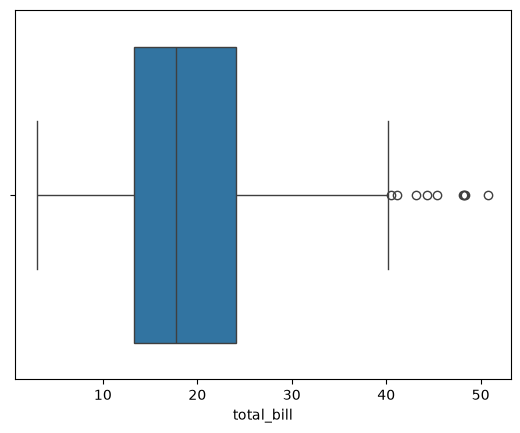

In [8]:
sns.boxplot(x=df['total_bill'])

<Axes: xlabel='total_bill', ylabel='Count'>

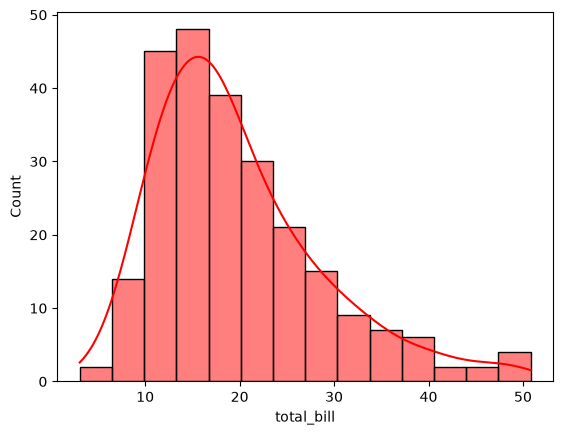

In [9]:
sns.histplot(df['total_bill'], kde=True, color = 'red')

In [10]:
df1 = sns.load_dataset('iris')

In [11]:
df1.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_width', ylabel='Count'>

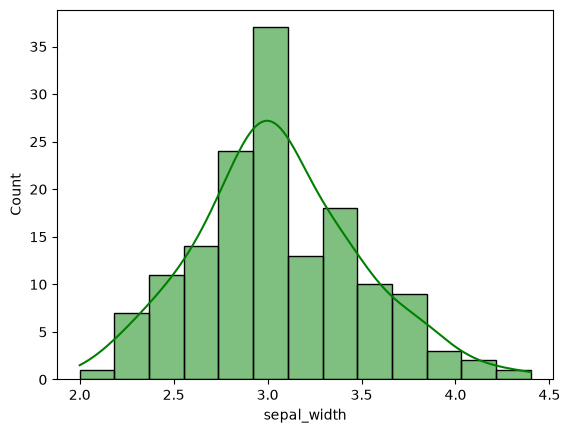

In [12]:
sns.histplot(df1['sepal_width'], kde=True, color = 'green')

C:\Users\Ishaan Rastogi\AppData\Local\Temp\ipykernel_2410668\2847587401.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df1['species'], palette = 'Set1')


<Axes: xlabel='species', ylabel='count'>

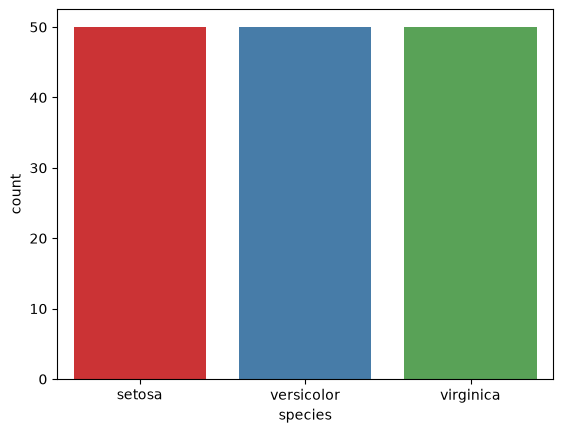

In [13]:
sns.countplot(x=df1['species'], palette = 'Set1')

In [14]:
# IQR

Percentile = np.percentile(df1['sepal_length'], [25,75])
Q1 = Percentile[0]
Q3 = Percentile[1]
IQR = Q3 - Q1
L = Q1 - 1.5*(IQR)
R = Q3 + 1.5*(IQR)
print(f"1st Quartile: {Q1}, 3rd Quartile: {Q3}, IQR: {IQR}\nLower Limit: {L}, Upper Limit: {R}")

1st Quartile: 5.1, 3rd Quartile: 6.4, IQR: 1.3000000000000007
Lower Limit: 3.1499999999999986, Upper Limit: 8.350000000000001


In [15]:
## Define our dataset
dataset= [11,10,12, 14, 12, 15, 14, 13, 15, 102, 12, 14, 17, 19, 107, 10, 13, 12, 14, 12, 108, 12, 11, 14, 13, 15, 10, 15, 12, 10, 14, 13, 15, 10]

In [16]:
# Z-Score

outliers = []

def detect_outlier(data):
    threshold = 3 # 3rd standard deviation
    mean = np.mean(data)
    std = np.std(data)

    for i in data:
        if std != 0:
            z_score = (i-mean)/std
            if np.abs(z_score) > threshold: # abs - to round off
                outliers.append(i)
        else:
            return 0
    print(f"Outliers: {outliers}")
detect_outlier(dataset)

Outliers: [102, 107, 108]


<Axes: >

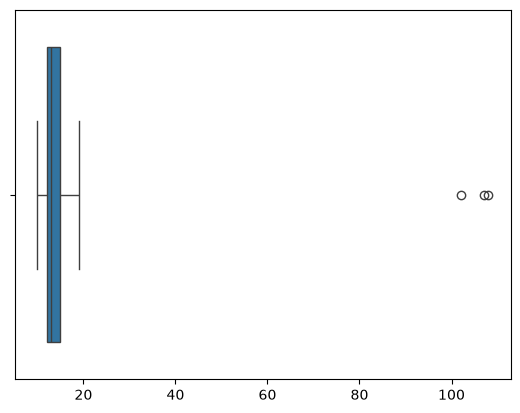

In [17]:
sns.boxplot(x=dataset)

In [18]:
# Removing outliers

new_dataset = [i for i in dataset if i not in outliers] # Vectorization - list comprehension

# Z Test

Suppose the IQ in a certain population is normally distributed with a mean of u = 100 and standard deviation of σ = 15. A researcher wants to know if a new drug affects IQ levels, so he recruits 20 patients to try it and records their IQ levels. The following code shows how to perform a one sample z-test in Python to determine if the new drug causes a significant difference in IQ levels:

In [19]:
from statsmodels.stats.weightstats import ztest

# enter IQ levels for 20 patients
data = [88, 92, 94, 94, 96, 97, 97, 97, 99, 99, 105, 109, 109, 109, 110, 112, 112, 113, 114, 115]

ztest(data, value=100) # Output: (z_statistic, p_value)

(np.float64(1.5976240527147705), np.float64(0.11012667014384257))

# T Test

In [20]:
## t -test

ages = [10, 20, 35, 50, 28, 40, 55, 18, 16, 55, 30, 25, 43, 18, 30, 28, 14, 24, 16, 17, 32, 35, 26, 27, 65, 18, 43, 23, 21, 20, 19, 70]
m = np.mean(ages)
m

np.float64(30.34375)

In [21]:
sample_size = 10
age_sample = np.random.choice(ages, sample_size)
age_sample

array([18, 26, 35, 23, 16, 14, 70, 28, 40, 26])

In [24]:
np.mean(age_sample)

np.float64(29.6)

In [22]:
from scipy.stats import ttest_1samp
ttest_1samp(age_sample, m) # Output: (t_statistic, p_value)

TtestResult(statistic=np.float64(-0.14389472508950488), pvalue=np.float64(0.8887540755479887), df=np.int64(9))

In [25]:
import scipy.stats as stats
import math
np.random.seed(6)
school_ages = stats.poisson.rvs(loc=18, mu=35, size=1500)
classA_ages = stats.poisson.rvs(loc=18, mu=30, size=60)

In [26]:
classA_ages.mean()

np.float64(46.9)

In [41]:
results = ttest_1samp(classA_ages, popmean=school_ages.mean()) # popmean saves mean into pvalue

In [43]:
if results.pvalue < 0.05:
    print("Reject H0")
else:
    print("Accept H0")

Reject H0


# Correlation

In [47]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [50]:
df.corr(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


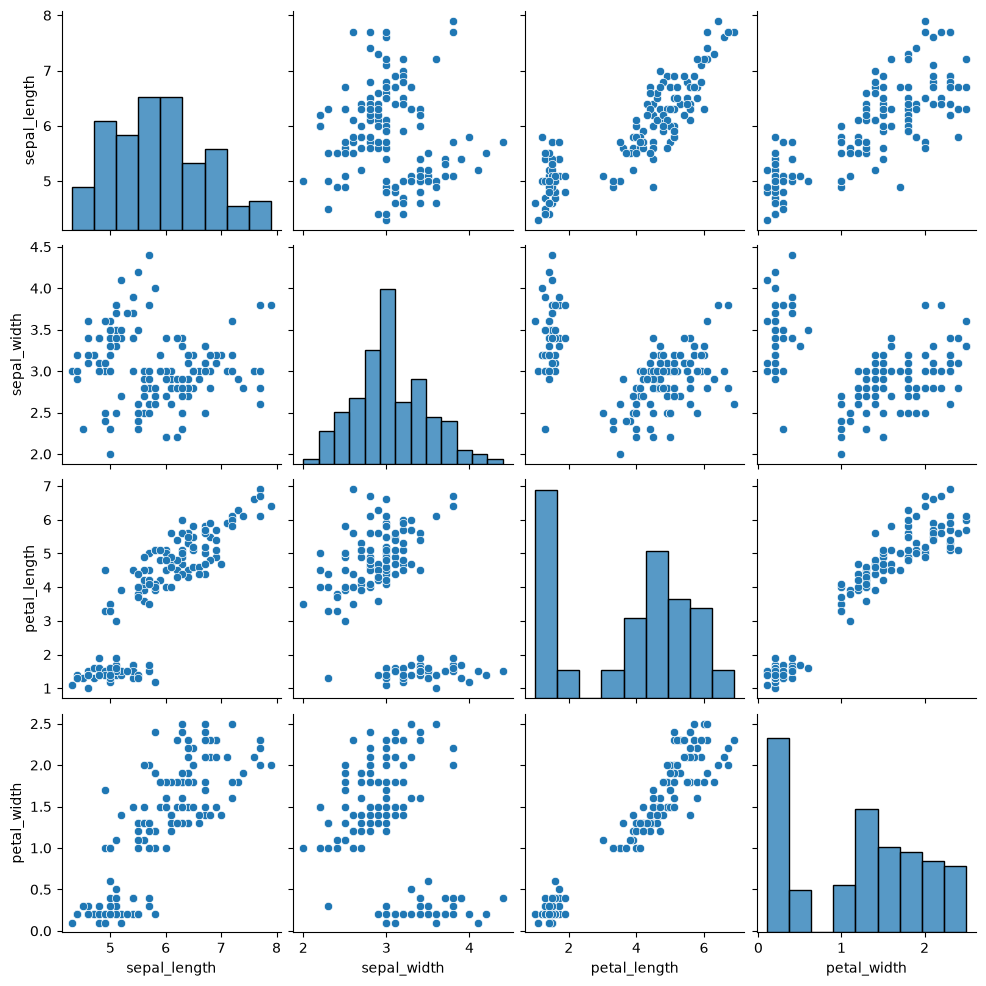

In [51]:
sns.pairplot(df)